tring: 2
[(12, 17), (1, 6), (8, 10), (11, 14), (15, 2), (13, 3), (16, 1), (5, 3), (1, 9), (2, 1), (3, 7), (2, 3), (2, 4)]
[0, 0, 0, 0, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
tring: 3
[(12, 9), (11, 1), (16, 6), (17, 2), (1, 7), (14, 5), (5, 3), (15, 3), (5, 2), (13, 4), (5, 4), (1, 3), (1, 8), (2, 10)]
[0, 0, 1, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
tring: 4
[(9, 10), (14, 15), (2, 1), (3, 11), (1, 4), (13, 2), (16, 3), (12, 5), (2, 6), (5, 1), (17, 1), (8, 4), (7, 5), (4, 3)]
[0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
tring: 5
[(3, 5), (11, 17), (4, 15), (7, 8), (12, 4), (9, 5), (3, 1), (10, 1), (6, 2), (14, 3), (4, 13), (3, 2), (16, 2), (1, 4)]
[0, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
tring: 6
[(10, 3), (5, 11), (9, 4), (13, 3), (15, 1), (7, 6), (17, 14), (2, 5), (2, 4), (2, 16), (1, 12), (2, 8), (1, 4), (1, 3)]
[0, 0, 0, 1, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
tring: 7
[(14, 7), (12, 17), (2, 9), (5, 2), (13, 15), (6, 2), (8, 16), (10, 1), (1

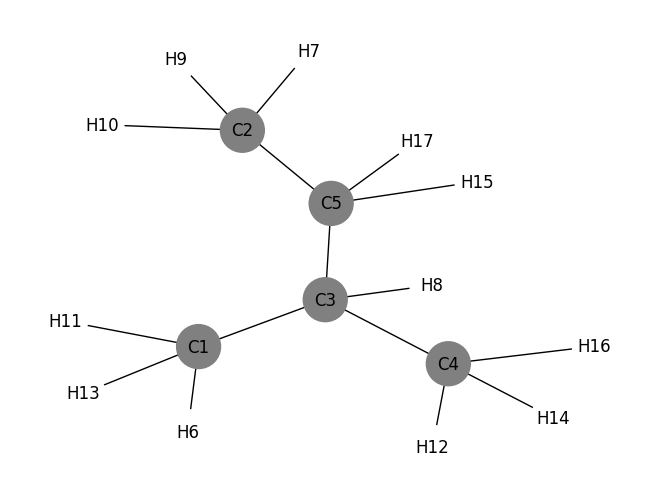

In [63]:
import random

# 그래프 클래스
class Graph:
    # 변수 정리
    def __init__(self, v):
        self.v = v							#정점 수
        self.edge = []						#간선 리스트
        self.parent = list(range(v+1))		#부모 정점 기록(+1은 인덱스 0안쓰려고)
        self.valence = [0]
        self.tring = 1
        self.result = []

    # 간선 추가
    def add(self, a, b, w):
        self.edge.append((w, a, b))

    # 정점이 속한 집합 찾기
    def find(self, v):
        if self.parent[v] == v:
            return v
        self.parent[v] = self.find(self.parent[v])
        return self.parent[v]

    # 두 정점이 속한 집합 합치기
    def union(self, a, b):
        p1 = self.find(a)
        p2 = self.find(b)

        if p1 < p2:
            self.parent[p2] = p1
        else:
            self.parent[p1] = p2

    # 크루스칼 알고리즘
    def kruskal(self):
        self.tring += 1
        print("tring: "+str(self.tring))
        self.result = []
        self.edge.sort() # 간선 오름차순 정렬
        for w, a, b in self.edge:
            if self.find(a) != self.find(b): # 순환성이 없는 경우
                if self.valence[a] != 0 and self.valence[b] != 0:
                    self.union(a, b) # 부모 정점 갱신
                    self.result.append((a, b)) # 간선 추가
                    self.valence[a]-=1
                    self.valence[b]-=1

        return self.result

    #몬테카를로 알고리즘(분자 구조가 성립하는 최대 신장 트리)
    def monte_carlo(self, C, O, H):
        self.edge = []
        self.parent = list(range(C+O+H+1))
        self.valence = [0] + [4] * C + [2] * O + [1] * H

        node=list(range(C+O+H+1)) #간선 추가를 위한 리스트
        node.remove(0)
        for i in node:
            for j in node:
                if i != j:
                    self.add(i, j, random.randrange(1,(C+O+H)**2))

        self.kruskal()
        print(self.result)
        print(self.valence)

        if self.valence.count(4) != 0 or len(self.result) != C+O+H-1:
            self.monte_carlo(C, O, H)
        return self.result, self.valence

    #이중 결합, 고리 형성
    def monte_carlo2(self, C, O, H, initial_valence):
      atom = C+O+H
      print(id(initial_valence), id(self.valence))
      print("몬테카를로2")
      self.valence = initial_valence[:] #가변 객체 참조 시 메모리 주소 중복 방지
      node_index = list(filter(lambda x: valence[x] != 0, range(len(self.valence))))
      v = len(node_index)
      self.edge = []
      self.parent = list(range(atom+1))

      for i in node_index:
          for j in node_index:
              if i != j:
                  self.add(i, j, random.randrange(1,v**2))

      self.kruskal()
      print(self.result)
      if self.tring < 500:
        if (self.valence.count(0) == len(self.valence)):
            print("나가요")
            print(self.valence)
            return self.result
        elif (self.monte_carlo3()):
            print("2 한번 더 돌아")
            return self.monte_carlo2(C, O, H, initial_valence)
        else:
            return self.result
      else:
        print("안정한 분자 구조를 찾지 못했습니다.")
        return []

    #삼중, 사중 결합
    def monte_carlo3(self):
      print("multiple before valence: "+str(self.valence))
      zero_count = self.valence.count(0)
      num_count = len(self.valence) - zero_count

      if zero_count != 0 and num_count == 1:
        return 1

      else:
          print("다중 결합 간선 추가")
          num_index = list(filter(lambda x: self.valence[x] != 0, range(len(self.valence)))) #0을 제외
          print((num_index[0], num_index[1]))
          print("self.valence: "+str(self.valence))
          self.result.append((num_index[0], num_index[1])) # 간선 추가
          self.valence[num_index[0]]-=1
          self.valence[num_index[1]]-=1
          print("multiple after valence: "+str(self.valence))
          if self.valence.count(0) != len(self.valence):
            print("3 다시 돌아")
            return self.monte_carlo3()
          else:
            return 0


C=5
O=0
H=12
atom=C+O+H
if((4*C+2*O+H)/2 != int((4*C+2*O+H)/2)):
    print("안정한 분자 구조를 찾지 못했습니다.")

g = Graph(atom)
result = 0
valence = 0
for u in g.monte_carlo(C, O, H):
    if result == 0:
        result = u
        print(u)
    else:
        valence = u[:] #가변 객체 참조 시 메모리 주소 중복 방지
result2 = g.monte_carlo2(C, O, H, valence)
graph=result+result2
graph.sort()
print(graph)

#다중 결합 간선 인덱스 찾기
graph2 = graph[:]
multi = {2: [], 3: [], 4: []}
for i in range(1, len(graph2)):
    if type(graph2[i]) != int:
      same_index = [j for j, value in enumerate(graph2) if value == graph2[i]] #같은 값들의 인덱스
      reversed_index = [graph2.index(j) for j in graph2 if j == tuple(reversed(graph2[i]))] #뒤집은 값들의 인덱스
      if len(same_index) + len(reversed_index) == 2:
          multi[2].append(graph2[i])
          for k in same_index: graph2[k] = k
          for l in reversed_index: graph2[l] = l
      if len(same_index) + len(reversed_index) == 3:
          multi[3].append(graph2[i])
          for k in same_index: graph2[k] = k
          for l in reversed_index: graph2[l] = l
      if len(same_index) + len(reversed_index) == 4:
          multi[4].append(graph2[i])
          for k in same_index: graph2[k] = k
          for l in reversed_index: graph2[l] = l
print(graph)
print(multi)

#시각화
import matplotlib.pyplot as plt
import networkx as nx
g1=nx.Graph()

labeldict = {}
node_colors = []

g1.add_node(0, label='trash node')
for i in range(0, C):
    g1.add_node(i + 1)
    labeldict[i + 1] = "C"+str(i + 1)
    node_colors.append('gray')
for i in range(0, O):
    g1.add_node(i + C + 1)
    labeldict[i + C + 1] = "O"+str(i + C + 1)
    node_colors.append('red')
for i in range(0, H):
    g1.add_node(i + C + O + 1)
    labeldict[i + C + O + 1] = "H"+str(i + C + O + 1)
    node_colors.append('white')
g1.remove_node(0)

g1.add_edges_from(graph)

pos = nx.kamada_kawai_layout(g1)
nx.draw(g1, pos, labels=labeldict,  node_color=node_colors, with_labels=True, node_size=1000)

if multi[2] != []:
  for i in multi[2]:
    nx.draw_networkx_edges(g1, pos, edgelist=multi[2], edge_color='white', width=1.1, arrowstyle='-', arrows=True)
    nx.draw_networkx_edges(g1, pos, edgelist=multi[2], connectionstyle='arc3, rad = 0.1', arrowstyle='-', arrows=True)
    nx.draw_networkx_edges(g1, pos, edgelist=multi[2], connectionstyle='arc3, rad = -0.1', arrowstyle='-', arrows=True)
if multi[3] != []:
  for i in multi[3]:
    nx.draw_networkx_edges(g1, pos, edgelist=multi[3], connectionstyle='arc3, rad = 0.2', arrowstyle='-', arrows=True)
    nx.draw_networkx_edges(g1, pos, edgelist=multi[3], connectionstyle='arc3, rad = -0.2', arrowstyle='-', arrows=True)
if multi[4] != []:
  for i in multi[4]:
    nx.draw_networkx_edges(g1, pos, edgelist=multi[4], edge_color='white', arrowstyle='-', arrows=True)
    nx.draw_networkx_edges(g1, pos, edgelist=multi[4], connectionstyle='arc3, rad = 0.2', arrowstyle='-', arrows=True)
    nx.draw_networkx_edges(g1, pos, edgelist=multi[4], connectionstyle='arc3, rad = 0.1', arrowstyle='-', arrows=True)
    nx.draw_networkx_edges(g1, pos, edgelist=multi[4], connectionstyle='arc3, rad = -0.1', arrowstyle='-', arrows=True)
    nx.draw_networkx_edges(g1, pos, edgelist=multi[4], connectionstyle='arc3, rad = -0.2', arrowstyle='-', arrows=True)